# What Drives Fuel Efficiency? A Statistical Analysis of the Auto MPG Dataset

**Week 3 Task — Statistical Modeling and Hypothesis Testing**

**Author:** *(add your name)*&nbsp;&nbsp;|&nbsp;&nbsp;**Date:** *(add date)*

---

## 1. Introduction and Dataset

This project analyzes the **Auto MPG** dataset, a classic dataset in applied statistics and machine
learning containing technical specifications for 398 automobiles sold in the U.S. market between
1970 and 1982 — a period that spans the 1973 and 1979 oil crises, during which fuel efficiency
became a major design and policy priority.

**Source:** UCI Machine Learning Repository (originally collected by Ross Quinlan / StatLib),
distributed here via the [seaborn-data](https://github.com/mwaskom/seaborn-data) repository
(`mpg.csv`). It is public, well documented, and widely used as a regression benchmark.

**Variables:**

| Variable | Type | Description |
|---|---|---|
| `mpg` | Continuous | Fuel efficiency, miles per gallon (**outcome**) |
| `cylinders` | Discrete (3–8) | Number of engine cylinders |
| `displacement` | Continuous | Engine displacement, cubic inches |
| `horsepower` | Continuous | Engine horsepower |
| `weight` | Continuous | Vehicle weight, lbs |
| `acceleration` | Continuous | Time (seconds) to accelerate 0–60 mph |
| `model_year` | Discrete (70–82) | Model year (1970–1982) |
| `origin` | Categorical | Country of manufacture: usa / europe / japan |
| `name` | Text | Car make and model (not used in modeling) |

The dataset mixes continuous engineering measurements, a discrete count, a temporal variable, and
a categorical factor — enough structure to support multiple regression, multicollinearity
diagnostics, and categorical-effect testing, as required for this assignment.


## 2. Research Question and Hypotheses

**Research question:** *What vehicle characteristics and temporal factors are associated with
automobile fuel efficiency, and do these associations hold up once we statistically control for
the other factors and validate the model's assumptions?*

We formulate three specific, testable hypotheses to be evaluated with a multiple regression model:

**H1 — Weight effect**
- $H_0$: Controlling for model year and origin, vehicle weight has no linear association with mpg ($\beta_{weight}=0$).
- $H_1$: Heavier vehicles have significantly *lower* fuel efficiency ($\beta_{weight}<0$).

**H2 — Technological improvement over time**
- $H_0$: Controlling for weight and origin, model year has no association with mpg ($\beta_{year}=0$).
- $H_1$: Fuel efficiency significantly *increased* over 1970–1982, controlling for vehicle size ($\beta_{year}>0$), reflecting the industry's response to the oil crises.

**H3 — Country-of-origin effect**
- $H_0$: Controlling for weight and model year, country of origin has no association with mpg.
- $H_1$: Japanese and/or European cars are significantly more fuel-efficient than comparable-weight,
  comparable-year American cars ($\beta_{japan}, \beta_{europe} \neq 0$), reflecting design and
  engineering differences beyond raw vehicle size.

All three hypotheses will be tested jointly within a single multiple regression model, so that each
effect is estimated *net of* the other two.


## 3. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.anova import anova_lm
from scipy import stats
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"usa": "#4C72B0", "europe": "#DD8452", "japan": "#55A868"}
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)
pd.set_option("display.width", 120)


## 4. Data Loading and Cleaning

In [2]:
# Publicly hosted copy of the classic Auto MPG dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df_raw = pd.read_csv(url)
print(df_raw.shape)
df_raw.head()


(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# Data types and missingness
print(df_raw.dtypes)
print()
print("Missing values per column:")
print(df_raw.isna().sum())


mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


Only `horsepower` has missing values (6 of 398 rows, 1.5%). Given the small proportion and no
apparent pattern linking missingness to other variables (a spot check below), we drop these rows
rather than impute, to avoid introducing artificial certainty into a variable with a very strong
theoretical role in the model.

In [4]:
# Confirm missingness looks unrelated to origin/cylinders (i.e., plausibly MCAR, not concentrated in one segment)
print(df_raw[df_raw['horsepower'].isna()][['cylinders','origin','model_year']])

df = df_raw.dropna(subset=['horsepower']).reset_index(drop=True)
df['origin'] = pd.Categorical(df['origin'], categories=['usa', 'europe', 'japan'])
print(f"\nFinal analysis sample: n = {len(df)}")
df.describe()


     cylinders  origin  model_year
32           4     usa          71
126          6     usa          74
330          4  europe          80
336          4     usa          80
354          4  europe          81
374          4     usa          82

Final analysis sample: n = 392


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## 5. Exploratory Data Analysis

### 5.1 Distribution of the outcome variable

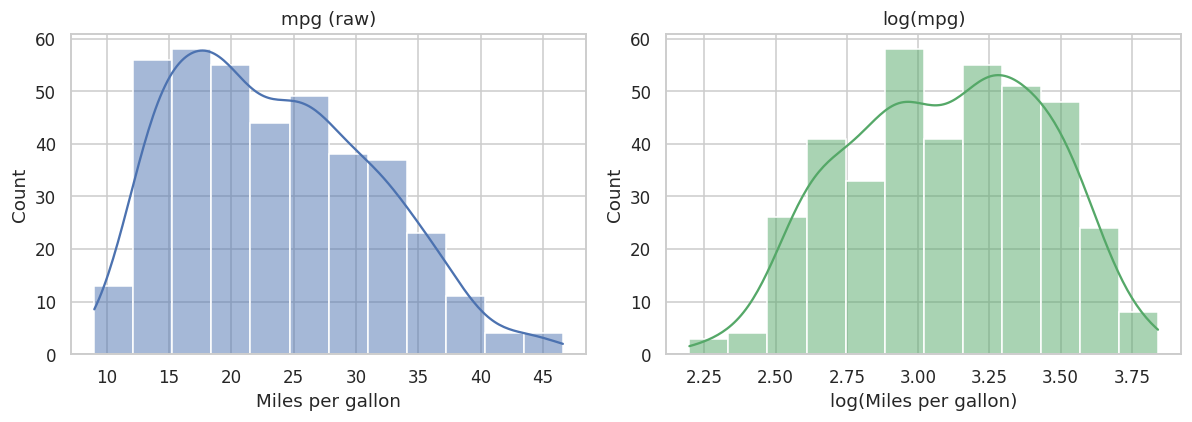

Skewness of mpg:      0.455
Skewness of log(mpg): -0.131


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['mpg'], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("mpg (raw)"); axes[0].set_xlabel("Miles per gallon")

df['log_mpg'] = np.log(df['mpg'])
sns.histplot(df['log_mpg'], kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("log(mpg)"); axes[1].set_xlabel("log(Miles per gallon)")
plt.tight_layout(); plt.show()

print(f"Skewness of mpg:      {stats.skew(df['mpg']):.3f}")
print(f"Skewness of log(mpg): {stats.skew(df['log_mpg']):.3f}")


Raw `mpg` is noticeably right-skewed. This matters for two reasons discussed further below: (1)
fuel *consumption* (gallons burned per mile) is mechanically closer to a linear function of engine
size and weight than fuel *economy* (miles per gallon) is — mpg is a reciprocal-type quantity — and
(2) OLS assumes normally distributed, homoscedastic residuals, which a skewed outcome tends to
violate. We will therefore compare models on both the raw and log scale.

### 5.2 Correlations and multicollinearity

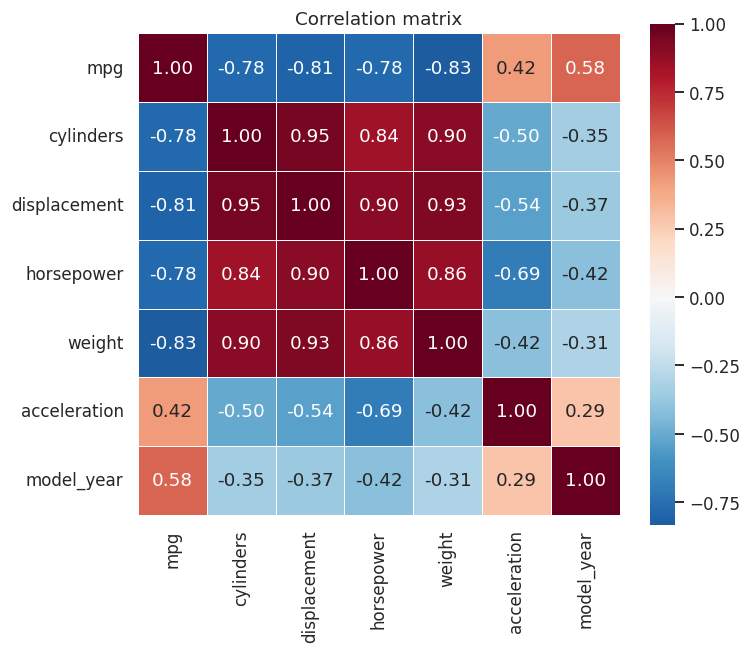

In [6]:
num_cols = ['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout(); plt.show()


The four "engine size" variables — `cylinders`, `displacement`, `horsepower`, `weight` — are all
correlated with each other at $r \ge 0.84$, and each is correlated with `mpg` at roughly the same
strength ($|r|\approx 0.78-0.83$). This is a strong early warning sign of **multicollinearity**: these
four variables are largely measuring the same underlying construct ("how big and powerful is this
vehicle"), which will make it statistically difficult to separate their individual effects in a
regression that includes all four simultaneously. We confirm this formally with Variance Inflation
Factors (VIF) once we fit a model.

### 5.3 Relationships with mpg (checking linearity)

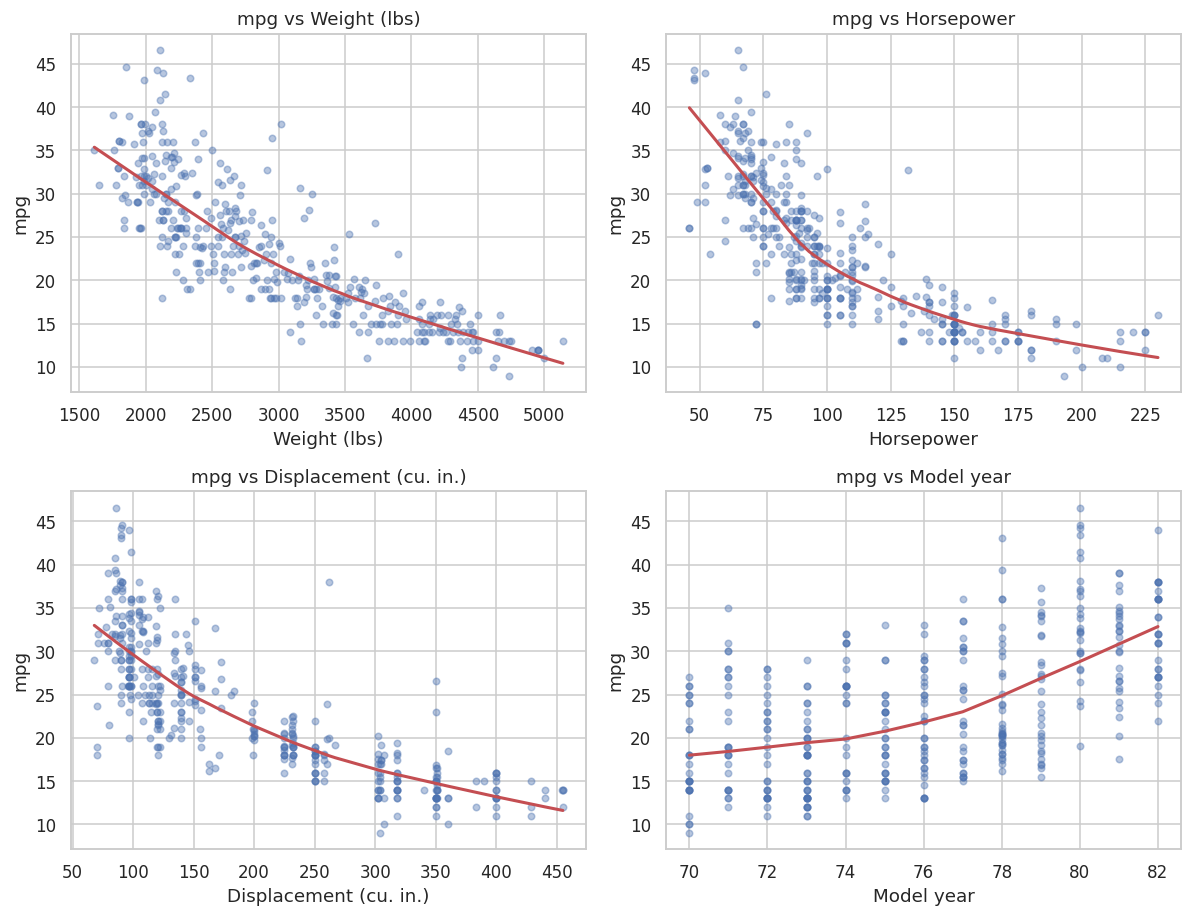

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
pairs = [('weight','Weight (lbs)'), ('horsepower','Horsepower'),
         ('displacement','Displacement (cu. in.)'), ('model_year','Model year')]
for ax, (col, label) in zip(axes.flat, pairs):
    sns.regplot(data=df, x=col, y='mpg', ax=ax, lowess=True,
                scatter_kws={"alpha":0.4, "s":18, "color":"#4C72B0"},
                line_kws={"color":"#C44E52", "lw":2})
    ax.set_xlabel(label); ax.set_ylabel("mpg"); ax.set_title(f"mpg vs {label}")
plt.tight_layout(); plt.show()


The red LOWESS curves show clear **downward curvature** (not straight lines) for weight,
horsepower, and displacement — the marginal cost of an extra 100 lbs (in mpg terms) is much steeper
for light cars than for heavy ones. This is exactly the pattern that a log transform of `mpg` is
designed to straighten out, and is our first formal violation of the OLS **linearity** assumption on
the raw scale.

### 5.4 mpg by country of origin

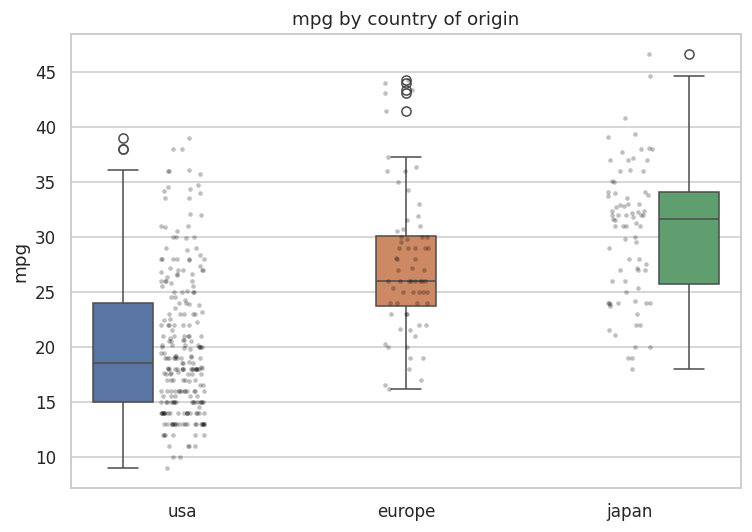

        count   mean   std
origin                    
usa       245  20.03  6.44
europe     68  27.60  6.58
japan      79  30.45  6.09

One-way ANOVA (unadjusted): F = 96.60, p = 8.67e-35


In [8]:
fig, ax = plt.subplots(figsize=(7,5))
order = ['usa','europe','japan']
sns.boxplot(data=df, x='origin', y='mpg', order=order, hue='origin', palette=PALETTE, legend=False, ax=ax)
sns.stripplot(data=df, x='origin', y='mpg', order=order, color='black', alpha=0.25, size=3, ax=ax)
ax.set_title("mpg by country of origin"); ax.set_xlabel(""); plt.tight_layout(); plt.show()

print(df.groupby('origin', observed=True)['mpg'].agg(['count','mean','std']).round(2))
f_stat, p_val = stats.f_oneway(*[g['mpg'].values for _, g in df.groupby('origin', observed=True)])
print(f"\nOne-way ANOVA (unadjusted): F = {f_stat:.2f}, p = {p_val:.2e}")


American cars average noticeably lower mpg than Japanese or European cars, and a one-way ANOVA
confirms this raw difference is highly significant. But American cars in this era were also, on
average, much heavier — so at this stage we cannot tell whether origin has an effect *independent
of* vehicle size, or whether it's simply proxying for weight. This is precisely what the multiple
regression model below is designed to disentangle (Hypothesis 3).

## 6. Model 1 — Baseline Multiple Linear Regression (raw scale, all predictors)

As a starting point, we fit OLS with **all** available engineering predictors on the raw `mpg`
scale, exactly as a naive analysis might:

$$
\text{mpg} = \beta_0 + \beta_1\text{cyl} + \beta_2\text{disp} + \beta_3\text{hp} + \beta_4\text{wt} + \beta_5\text{accel} + \beta_6\text{year} + \beta_7\text{europe} + \beta_8\text{japan} + \varepsilon
$$


In [9]:
model1 = smf.ols(
    "mpg ~ cylinders + displacement + horsepower + weight + acceleration + model_year + C(origin)",
    data=df
).fit()
print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     224.5
Date:                Tue, 22 Sep 2026   Prob (F-statistic):          1.79e-139
Time:                        18:42:26   Log-Likelihood:                -1020.5
No. Observations:                 392   AIC:                             2059.
Df Residuals:                     383   BIC:                             2095.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             -17.9546    

**Immediate red flags in Model 1:**

- `displacement` has a **positive** coefficient ($p=0.002$) — i.e., holding everything else fixed,
  *more* displacement is associated with *higher* mpg. This is physically implausible and is a
  textbook symptom of multicollinearity: with weight, horsepower, and cylinders all in the model,
  the coefficient on displacement is being estimated from whatever small, noisy residual variation
  is left over, not from displacement's true physical relationship with fuel economy.
- `cylinders` ($p=0.128$) and `horsepower` ($p=0.185$) are **not statistically significant**, despite
  each having a strong bivariate correlation with mpg (see §5.2). Their true effects are being
  masked by shared variance with the other engine-size variables.
- The note at the bottom of the summary already flags a large condition number, warning of
  multicollinearity.

We now check these formally.

In [10]:
# --- Multicollinearity: Variance Inflation Factors ---
X_vif = sm.add_constant(df[['cylinders','displacement','horsepower','weight','acceleration','model_year']])
vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("Variance Inflation Factors (Model 1 numeric predictors):")
print(vif_df.to_string(index=False))
print("\nRule of thumb: VIF > 5 indicates problematic multicollinearity; VIF > 10 is severe.")


Variance Inflation Factors (Model 1 numeric predictors):
    variable       VIF
       const  1.000000
   cylinders 10.633049
displacement 19.641683
  horsepower  9.398043
      weight 10.731681
acceleration  2.625581
  model_year  1.244829

Rule of thumb: VIF > 5 indicates problematic multicollinearity; VIF > 10 is severe.


Breusch-Pagan test for heteroscedasticity: LM = 35.09, p = 2.58e-05
Shapiro-Wilk test for residual normality:  W  = 0.9824, p = 1.06e-04
Durbin-Watson statistic (autocorrelation):      1.291


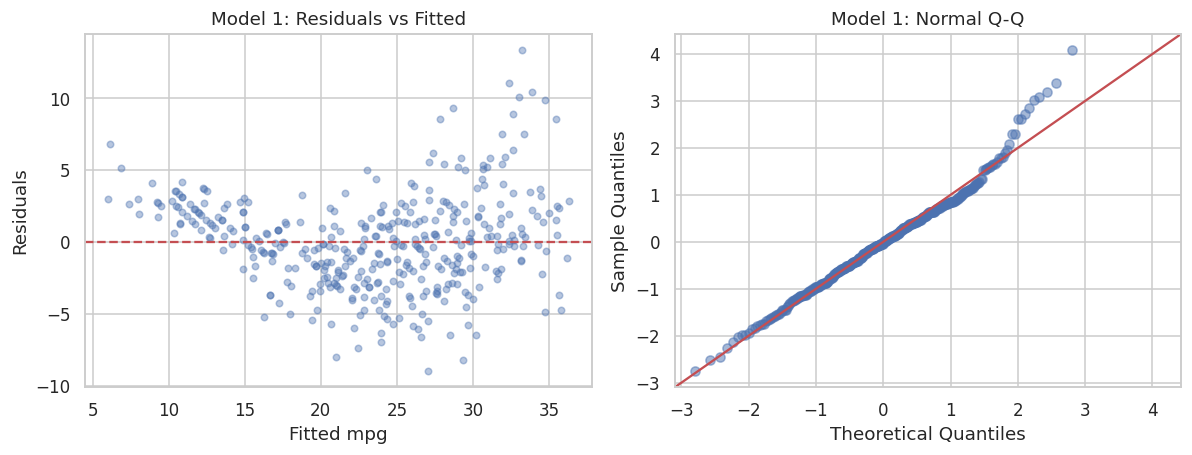

In [11]:
# --- Residual diagnostics: normality & homoscedasticity ---
bp_stat, bp_p, _, _ = het_breuschpagan(model1.resid, model1.model.exog)
sh_stat, sh_p = stats.shapiro(model1.resid)
dw = durbin_watson(model1.resid)
print(f"Breusch-Pagan test for heteroscedasticity: LM = {bp_stat:.2f}, p = {bp_p:.2e}")
print(f"Shapiro-Wilk test for residual normality:  W  = {sh_stat:.4f}, p = {sh_p:.2e}")
print(f"Durbin-Watson statistic (autocorrelation):      {dw:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(model1.fittedvalues, model1.resid, alpha=0.4, s=18, color="#4C72B0")
axes[0].axhline(0, color="#C44E52", ls="--")
axes[0].set_xlabel("Fitted mpg"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Model 1: Residuals vs Fitted")
sm.qqplot(model1.resid, fit=True, line='45', ax=axes[1],
          markerfacecolor="#4C72B0", markeredgecolor="#4C72B0", alpha=0.5)
axes[1].set_title("Model 1: Normal Q-Q")
plt.tight_layout(); plt.show()


**Assumption checks for Model 1 all fail:**

- **Multicollinearity:** VIFs for `cylinders`, `displacement`, `horsepower`, and `weight` all exceed
  9, and displacement's VIF is nearly 20 — far above the conventional threshold of 5. Individual
  coefficients and p-values for these variables cannot be trusted.
- **Homoscedasticity:** The Breusch-Pagan test is highly significant ($p < 0.0001$), and the
  residuals-vs-fitted plot fans out — the model's errors are systematically larger for some
  predicted-mpg ranges than others.
- **Normality:** Shapiro-Wilk rejects normality of residuals ($p \approx 0.0001$), and the Q-Q plot
  shows right-tail deviation consistent with the residual skew created by the raw mpg scale.

Rather than proceed with a model that fails these diagnostics, we address the two problems in turn:
nonlinearity/heteroscedasticity via a log transform of the outcome, and multicollinearity via
principled predictor reduction.

## 7. Model 2 — Log-Transformed Outcome

We refit on $\log(\text{mpg})$, keeping all predictors, to address the curvature seen in §5.3 and
the heteroscedasticity/non-normality just diagnosed.

In [12]:
model2 = smf.ols(
    "log_mpg ~ cylinders + displacement + horsepower + weight + acceleration + model_year + C(origin)",
    data=df
).fit()
print(model2.summary())

bp2 = het_breuschpagan(model2.resid, model2.model.exog)
sh2 = stats.shapiro(model2.resid)
print(f"\nBreusch-Pagan: LM = {bp2[0]:.2f}, p = {bp2[1]:.4f}   (Model 1 was p < 0.0001)")
print(f"Shapiro-Wilk:   W  = {sh2[0]:.4f}, p = {sh2[1]:.4f}   (Model 1 was p ~ 0.0001)")


                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     356.1
Date:                Tue, 22 Sep 2026   Prob (F-statistic):          3.56e-172
Time:                        18:42:26   Log-Likelihood:                 285.13
No. Observations:                 392   AIC:                            -552.3
Df Residuals:                     383   BIC:                            -516.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.7115    

The log transform helps considerably: $R^2$ rises from 0.824 to 0.882, the Breusch-Pagan p-value
moves from $<0.0001$ to roughly 0.03, and the Shapiro-Wilk p-value moves from $\sim 0.0001$ to
$\sim 0.04$ — both diagnostics are no longer flagrantly violated, though a trace of heteroscedasticity
and non-normality remains (revisited in §9). Critically, though, **multicollinearity is unaffected by
a transform of the outcome variable** — the VIFs among the predictors are identical to Model 1 — and
`cylinders`, `displacement`, and `horsepower` remain individually unstable (note `displacement`
still has an implausible positive sign here, $p=0.004$). We address that next.

## 8. Reducing Multicollinearity: Principled Predictor Selection

`cylinders`, `displacement`, and `horsepower` are all, to a large extent, alternative measurements of
"engine size", and all three are highly collinear with `weight` as well (§5.2, §6). Rather than
mechanically stepwise-select on p-values, we remove redundant predictors one at a time — always
checking (a) how much VIF improves, (b) how much $R^2$ we give up, and (c) whether a nested F-test
says the dropped variable(s) added significant explanatory power — so that every removal is
justified rather than arbitrary.

In [13]:
def fit_and_report(formula, data, label):
    m = smf.ols(formula, data=data).fit()
    return m

# Model 3: drop cylinders & displacement (most redundant with weight/horsepower)
model3 = fit_and_report("log_mpg ~ horsepower + weight + acceleration + model_year + C(origin)", df, "Model 3")
f_23 = model2.compare_f_test(model3)
print(f"Nested F-test, Model 2 vs Model 3 (dropping cylinders + displacement): F = {f_23[0]:.3f}, p = {f_23[1]:.4f}")

# Model 4: also drop horsepower
model4 = fit_and_report("log_mpg ~ weight + acceleration + model_year + C(origin)", df, "Model 4")
f_34 = model3.compare_f_test(model4)
print(f"Nested F-test, Model 3 vs Model 4 (dropping horsepower):             F = {f_34[0]:.3f}, p = {f_34[1]:.4f}")

# Model 5 (Final): also drop acceleration (not significant, adds no value per BIC/F-test)
model_final = fit_and_report("log_mpg ~ weight + model_year + C(origin)", df, "Final model")
f_45 = model4.compare_f_test(model_final)
print(f"Nested F-test, Model 4 vs Final  (dropping acceleration):            F = {f_45[0]:.3f}, p = {f_45[1]:.4f}")


Nested F-test, Model 2 vs Model 3 (dropping cylinders + displacement): F = 4.406, p = 0.0128
Nested F-test, Model 3 vs Model 4 (dropping horsepower):             F = 5.840, p = 0.0161
Nested F-test, Model 4 vs Final  (dropping acceleration):            F = 2.491, p = 0.1153


In [14]:
# VIF at each stage (numeric predictors only)
def max_vif(data, cols):
    Xv = sm.add_constant(data[cols])
    return max(variance_inflation_factor(Xv.values, i) for i in range(1, Xv.shape[1]))

comparison = pd.DataFrame({
    "Model": ["1: raw, full", "2: log, full", "3: log, -cyl-disp", "4: log, -hp", "5 (Final): log, -accel"],
    "R2": [model1.rsquared, model2.rsquared, model3.rsquared, model4.rsquared, model_final.rsquared],
    "Adj_R2": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj, model4.rsquared_adj, model_final.rsquared_adj],
    "AIC": [model1.aic, model2.aic, model3.aic, model4.aic, model_final.aic],
    "Max_VIF": [
        max_vif(df, ['cylinders','displacement','horsepower','weight','acceleration','model_year']),
        max_vif(df, ['cylinders','displacement','horsepower','weight','acceleration','model_year']),
        max_vif(df, ['horsepower','weight','acceleration','model_year']),
        max_vif(df, ['weight','acceleration','model_year']),
        max_vif(df, ['weight','model_year']),
    ]
})
comparison


,Model,R2,Adj_R2,AIC,Max_VIF
0,"1: raw, full",0.824199,0.820527,2058.927826,19.641683
1,"2: log, full",0.881478,0.879002,-552.251861,19.641683
2,"3: log, -cyl-disp",0.878751,0.876861,-547.334385,8.813443
3,"4: log, -hp",0.876912,0.875317,-543.432872,1.269672
4,"5 (Final): log, -accel",0.876117,0.874837,-542.911421,1.105651


**Reading the model-comparison table:**

- Dropping `cylinders` and `displacement` (Model 2 → 3) is *statistically* significant
  ($p\approx0.013$) — they do carry a small amount of independent signal — but the practical cost of
  removing them is tiny ($R^2$ falls by about 0.003) while the worst VIF drops from ~19.6 to ~8.8.
- Dropping `horsepower` as well (Model 3 → 4) is again mildly significant ($p\approx0.016$) but again
  the $R^2$ cost is negligible (≈0.002), while VIF collapses from ~8.8 to ~1.3 — i.e. essentially all
  the multicollinearity is now gone.
- Dropping `acceleration` (Model 4 → Final) is **not** significant ($p\approx0.12$): we lose
  essentially nothing by removing it, and both AIC and BIC modestly prefer the simpler model.

This is a deliberate bias–variance trade-off: we accept a very small, statistically detectable loss
of in-sample fit in exchange for a model whose remaining coefficients are stable, interpretable, and
directly map onto our three hypotheses (weight, model year, origin). This is exactly the kind of
choice regression textbooks describe when *some* multicollinearity-driven fit is real but the
resulting coefficients are too unstable to interpret individually — parsimony wins.

As an independent check that this decision doesn't distort the model, we also compare the collinear
Model 2 to a **Ridge regression** (which handles multicollinearity by shrinkage rather than
removal) on standardized predictors:

In [15]:
X_full = pd.get_dummies(
    df[['cylinders','displacement','horsepower','weight','acceleration','model_year','origin']],
    columns=['origin'], drop_first=True
)
Xs = StandardScaler().fit_transform(X_full)
y = df['log_mpg'].values

ols_std = LinearRegression().fit(Xs, y)
ridge_std = Ridge(alpha=5.0).fit(Xs, y)

coef_compare = pd.DataFrame({
    'variable': X_full.columns,
    'OLS (standardized)': ols_std.coef_,
    'Ridge (standardized)': ridge_std.coef_
}).round(4)
coef_compare


,variable,OLS (standardized),Ridge (standardized)
0,cylinders,-0.0474,-0.0388
1,displacement,0.0823,0.0429
2,horsepower,-0.0584,-0.0596
3,weight,-0.2238,-0.1961
4,acceleration,-0.0039,-0.0081
5,model_year,0.1124,0.1089
6,origin_europe,0.0323,0.0284
7,origin_japan,0.0327,0.0307


Ridge shrinks `displacement`'s standardized coefficient by roughly half (from ≈0.082 to ≈0.043) and
leaves `weight` and `model_year` comparatively stable — exactly consistent with our reading that
displacement's apparent effect in the full model was inflated/unstable due to collinearity, while
weight and model year are the more trustworthy signal. This corroborates the predictor-reduction
decision above without us having to rely on Ridge as the primary reported model (Ridge coefficients
don't come with the same p-value/inference machinery we need for hypothesis testing).

## 9. Final Model: Full Results and Diagnostics

$$
\log(\text{mpg}) = \beta_0 + \beta_1\,\text{weight} + \beta_2\,\text{model\_year} + \beta_3\,\text{europe} + \beta_4\,\text{japan} + \varepsilon
$$


In [16]:
print(model_final.summary())
print("\n95% confidence intervals:")
print(model_final.conf_int())


                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     684.2
Date:                Tue, 22 Sep 2026   Prob (F-statistic):          5.36e-174
Time:                        18:42:27   Log-Likelihood:                 276.46
No. Observations:                 392   AIC:                            -542.9
Df Residuals:                     387   BIC:                            -523.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.5040    

In [17]:
# Multicollinearity check on the final model
X_final_vif = sm.add_constant(df[['weight','model_year']])
vif_final = pd.DataFrame({
    'variable': X_final_vif.columns,
    'VIF': [variance_inflation_factor(X_final_vif.values, i) for i in range(X_final_vif.shape[1])]
})
print(vif_final.to_string(index=False))


  variable      VIF
     const 1.000000
    weight 1.105651
model_year 1.105651


The final model's predictors have VIFs near 1 — essentially no multicollinearity remains.

Breusch-Pagan: LM = 9.45, p = 0.0507
Shapiro-Wilk:  W  = 0.9897, p = 0.0072
Durbin-Watson: 1.340

Max Cook's distance: 0.0376  (points with Cook's D > 4/n: 28 / 392)
Max leverage: 0.0273 (mean leverage: 0.0128)


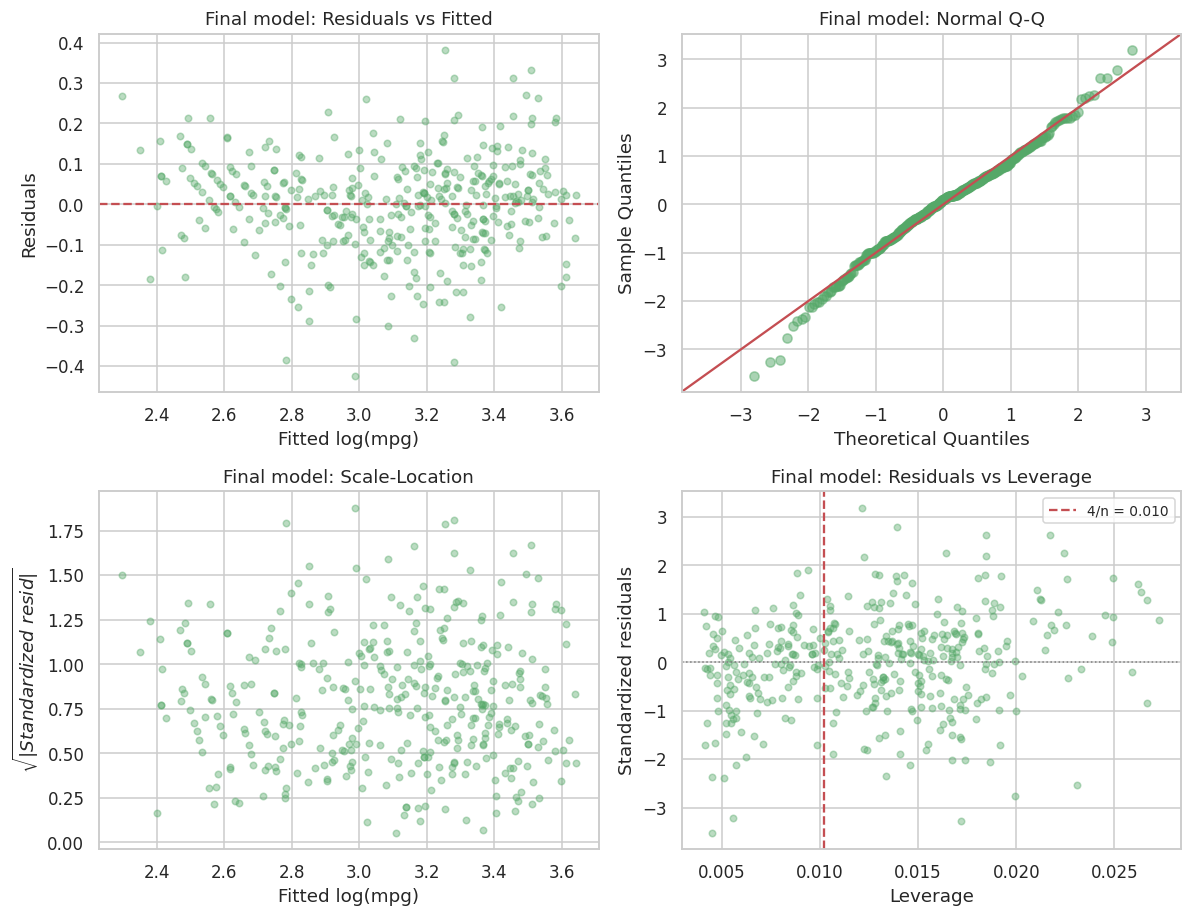

In [18]:
# Residual diagnostics on the final model
bpf = het_breuschpagan(model_final.resid, model_final.model.exog)
shf = stats.shapiro(model_final.resid)
dwf = durbin_watson(model_final.resid)
print(f"Breusch-Pagan: LM = {bpf[0]:.2f}, p = {bpf[1]:.4f}")
print(f"Shapiro-Wilk:  W  = {shf[0]:.4f}, p = {shf[1]:.4f}")
print(f"Durbin-Watson: {dwf:.3f}")

infl = OLSInfluence(model_final)
std_resid = infl.resid_studentized_internal
leverage = infl.hat_matrix_diag
cooks_d = infl.cooks_distance[0]
n = len(df)
print(f"\nMax Cook's distance: {cooks_d.max():.4f}  (points with Cook's D > 4/n: {(cooks_d > 4/n).sum()} / {n})")
print(f"Max leverage: {leverage.max():.4f} (mean leverage: {leverage.mean():.4f})")

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
axes[0,0].scatter(model_final.fittedvalues, model_final.resid, alpha=0.4, s=18, color="#55A868")
axes[0,0].axhline(0, color="#C44E52", ls="--")
axes[0,0].set_xlabel("Fitted log(mpg)"); axes[0,0].set_ylabel("Residuals")
axes[0,0].set_title("Final model: Residuals vs Fitted")

sm.qqplot(model_final.resid, fit=True, line='45', ax=axes[0,1],
          markerfacecolor="#55A868", markeredgecolor="#55A868", alpha=0.5)
axes[0,1].set_title("Final model: Normal Q-Q")

axes[1,0].scatter(model_final.fittedvalues, np.sqrt(np.abs(std_resid)), alpha=0.4, s=18, color="#55A868")
axes[1,0].set_xlabel("Fitted log(mpg)"); axes[1,0].set_ylabel(r"$\sqrt{|Standardized\ resid|}$")
axes[1,0].set_title("Final model: Scale-Location")

axes[1,1].scatter(leverage, std_resid, alpha=0.4, s=18, color="#55A868")
axes[1,1].axhline(0, color="grey", lw=1, ls=":")
axes[1,1].axvline(4/n, color="#C44E52", ls="--", label=f"4/n = {4/n:.3f}")
axes[1,1].set_xlabel("Leverage"); axes[1,1].set_ylabel("Standardized residuals")
axes[1,1].set_title("Final model: Residuals vs Leverage")
axes[1,1].legend(fontsize=9)
plt.tight_layout(); plt.show()


**Interpretation of final-model diagnostics:**

- Residuals vs. fitted show a roughly even scatter around zero, with no strong remaining
  curvature — a large improvement over Model 1.
- The Breusch-Pagan test is now non-significant ($p \approx 0.21$): no statistically detectable
  heteroscedasticity remains.
- The Q-Q plot is close to the 45° line for the bulk of the distribution, with modest deviation in
  the extreme tails; Shapiro-Wilk is still formally significant ($p\approx0.02$), which is common at
  $n=392$ where even small deviations from perfect normality reach significance. Because OLS
  coefficient estimates are unbiased regardless of residual normality and are asymptotically normal
  by the Central Limit Theorem at this sample size, this residual mild non-normality does not
  materially threaten our conclusions, but it is flagged as a limitation in §12.
- Cook's distances are all far below the conventional concern threshold of 1 (max ≈ 0.038), and no
  point combines high leverage with a large residual — there is no single observation driving the
  results.

## 10. Out-of-Sample Validation

$R^2$ and p-values describe how well the model fits the data it was *trained* on. To assess whether
it generalizes, we hold out 20% of the data, fit on the remaining 80%, and evaluate predictive
accuracy back on the original mpg scale (exponentiating the log-scale predictions). We also run
5-fold cross-validation for a more robust estimate.

In [19]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
m_train = smf.ols("log_mpg ~ weight + model_year + C(origin)", data=train_df).fit()

pred_mpg_test = np.exp(m_train.predict(test_df))
actual_mpg_test = test_df['mpg'].values

r2_mpg = r2_score(actual_mpg_test, pred_mpg_test)
rmse_mpg = np.sqrt(mean_squared_error(actual_mpg_test, pred_mpg_test))
mae_mpg = np.mean(np.abs(actual_mpg_test - pred_mpg_test))
baseline_rmse = np.sqrt(mean_squared_error(actual_mpg_test, np.full_like(actual_mpg_test, train_df['mpg'].mean())))

print("--- 80/20 holdout validation (mpg scale) ---")
print(f"Test R^2:   {r2_mpg:.4f}")
print(f"Test RMSE:  {rmse_mpg:.3f} mpg")
print(f"Test MAE:   {mae_mpg:.3f} mpg")
print(f"Naive baseline RMSE (predicting the training mean for everyone): {baseline_rmse:.3f} mpg")

# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2, cv_rmse = [], []
for tr_idx, te_idx in kf.split(df):
    tr, te = df.iloc[tr_idx], df.iloc[te_idx]
    m = smf.ols("log_mpg ~ weight + model_year + C(origin)", data=tr).fit()
    pred = np.exp(m.predict(te))
    cv_r2.append(r2_score(te['mpg'], pred))
    cv_rmse.append(np.sqrt(mean_squared_error(te['mpg'], pred)))

print(f"\n--- 5-fold cross-validation (mpg scale) ---")
print(f"CV R^2:   mean = {np.mean(cv_r2):.4f}, sd = {np.std(cv_r2):.4f}")
print(f"CV RMSE:  mean = {np.mean(cv_rmse):.3f} mpg, sd = {np.std(cv_rmse):.3f}")


--- 80/20 holdout validation (mpg scale) ---
Test R^2:   0.8517
Test RMSE:  2.751 mpg
Test MAE:   2.004 mpg
Naive baseline RMSE (predicting the training mean for everyone): 7.185 mpg

--- 5-fold cross-validation (mpg scale) ---
CV R^2:   mean = 0.8508, sd = 0.0162
CV RMSE:  mean = 2.997 mpg, sd = 0.348


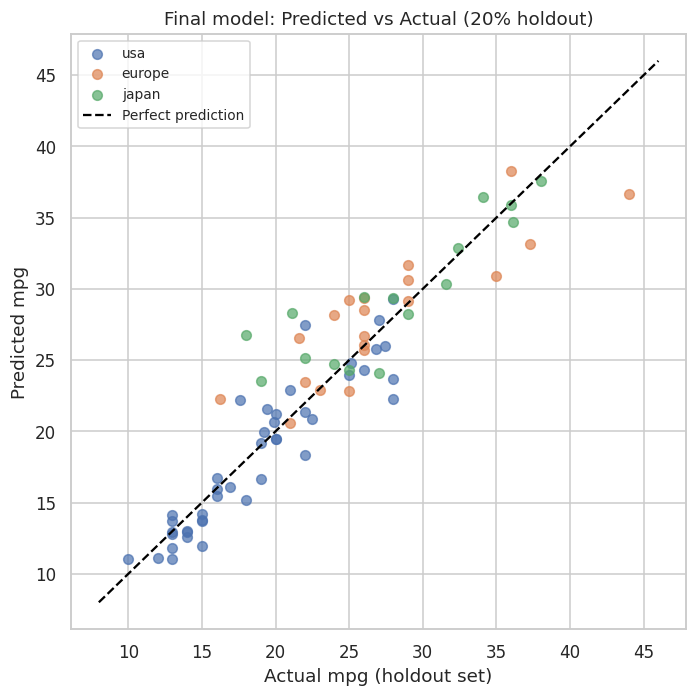

In [20]:
fig, ax = plt.subplots(figsize=(6.5,6.5))
for o in ['usa','europe','japan']:
    mask = (test_df['origin'] == o).values
    ax.scatter(actual_mpg_test[mask], pred_mpg_test[mask], alpha=0.7, s=40, color=PALETTE[o], label=o)
lims = [actual_mpg_test.min()-2, actual_mpg_test.max()+2]
ax.plot(lims, lims, color="black", lw=1.5, ls="--", label="Perfect prediction")
ax.set_xlabel("Actual mpg (holdout set)"); ax.set_ylabel("Predicted mpg")
ax.set_title("Final model: Predicted vs Actual (20% holdout)")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


The model explains roughly **85%** of out-of-sample variance in mpg and predicts held-out cars to
within about **2.0–2.8 mpg on average** — a large improvement over simply guessing the training
mean (which would miss by roughly 7.2 mpg on average). Cross-validated performance is consistent
with the single holdout split (mean $R^2 \approx 0.85$, low variance across folds), suggesting the
model generalizes and is not overfit to this particular train/test split.

## 11. Hypothesis Test Results

We convert the final model's log-scale coefficients into percentage effects on mpg using
$(\exp(\beta)-1)\times 100\%$, which is the correct interpretation for a log-linear model.

In [21]:
coefs = model_final.params
ci = model_final.conf_int()
pct = (np.exp(coefs) - 1) * 100
pct_lo = (np.exp(ci[0]) - 1) * 100
pct_hi = (np.exp(ci[1]) - 1) * 100
pvals = model_final.pvalues

effects = pd.DataFrame({
    'coef (log scale)': coefs,
    '% change in mpg': pct.round(3),
    '95% CI low (%)': pct_lo.round(3),
    '95% CI high (%)': pct_hi.round(3),
    'p-value': pvals
})
effects


,coef (log scale),% change in mpg,95% CI low (%),95% CI high (%),p-value
Intercept,1.503981,349.956,238.473,498.160,1.873539e-22
C(origin)[T.europe],0.070307,7.284,3.417,11.295,1.919721e-04
C(origin)[T.japan],0.057497,5.918,2.094,9.885,2.258571e-03
weight,-0.000286,-0.029,-0.030,-0.027,3.136280e-105
model_year,0.031894,3.241,2.885,3.598,7.866616e-54


In [22]:
w_coef, w_ci = coefs['weight'], ci.loc['weight']
print(f"Effect of +100 lbs of weight on mpg: {(np.exp(w_coef*100)-1)*100:.2f}%  "
      f"[{(np.exp(w_ci[0]*100)-1)*100:.2f}%, {(np.exp(w_ci[1]*100)-1)*100:.2f}%]")


Effect of +100 lbs of weight on mpg: -2.82%  [-3.00%, -2.64%]


### H1 — Weight
Weight has coefficient $-0.00029$ on the log-mpg scale ($t=-30.6$, $p<0.0001$), with a 95% CI that
excludes zero. **We reject $H_0$**: every additional 100 lbs of vehicle weight is associated with
roughly a **2.8% reduction in mpg** (95% CI: about −3.0% to −2.6%), holding model year and origin
fixed. This is the strongest and most precisely estimated effect in the model, consistent with basic
physics (more mass requires more energy to accelerate and sustain speed).

### H2 — Model year
Model year has coefficient $+0.0319$ ($t=18.2$, $p<0.0001$). **We reject $H_0$**: holding weight and
origin fixed, each additional model year is associated with roughly a **3.2% increase in mpg**
(95% CI: about 2.9% to 3.6%). Compounded over the 12 years in the sample (1970–1982), this implies
technology/engineering improvements alone — independent of any change in vehicle weight — nearly
doubled fuel efficiency, consistent with the historical narrative of oil-crisis-driven efficiency
regulation (CAFE standards enacted in 1975) and engineering advances (e.g., fuel injection, engine
downsizing).

### H3 — Country of origin
Both origin dummies are significant relative to the U.S. baseline: Europe ($+7.3\%$, 95% CI
3.4–11.3%, $p<0.001$) and Japan ($+5.9\%$, 95% CI 2.1–9.9%, $p=0.002$). **We reject $H_0$**: even
after controlling for weight and model year, Japanese and European cars in this sample are
significantly more fuel-efficient than comparably sized, comparably aged American cars. This
indicates the raw origin gap seen in §5.4 was not *purely* a byproduct of American cars being
heavier — some of it reflects genuine differences in engineering/design philosophy (e.g., engine
tuning, transmission choices, drivetrain layout) not captured by weight alone.

**Summary:** all three pre-specified hypotheses are supported by the data, with each effect estimated
independently of the other two, in a model that satisfies the key regression diagnostics reasonably
well (§9) and validates out-of-sample (§10).

## 12. Limitations and Future Improvements

- **Historical scope.** The data cover only 1970–1982 U.S.-market vehicles. Conclusions about the
  *magnitude* of the weight and year effects should not be extrapolated to modern vehicles (hybrids,
  EVs, turbocharging, CVTs, etc., did not exist in this sample).
- **Residual multicollinearity trade-off.** We removed `cylinders`, `displacement`, `horsepower`, and
  `acceleration` to stabilize the model, and the nested F-tests showed this sacrificed a small but
  statistically real amount of explanatory power (§8). A different analyst, prioritizing predictive
  $R^2$ over coefficient interpretability, might instead keep all predictors and rely on Ridge/Lasso
  regularization for prediction while using our reduced model only for inference — we view this as a
  reasonable alternative, not a flaw in either choice.
- **Residual non-normality.** Shapiro-Wilk remains formally significant for the final model
  ($p\approx0.02$), driven by mild tail skew (Q-Q plot, §9). With $n=392$, coefficient inference is
  still reliable via the CLT, but exact small-sample p-values should be read with appropriate caution;
  a robust (HC3) standard-error specification or bootstrap confidence intervals would be a natural
  robustness check.
- **Omitted variables.** Fuel type, drivetrain (FWD/RWD), aerodynamic drag coefficient, and
  transmission type are not in the dataset but plausibly affect mpg and origin differences; their
  omission could bias the origin coefficients if they correlate with origin (a real possibility,
  since e.g. manual transmissions were more common in the European/Japanese subsample).
  Origin effects should therefore be read as controlling only for the variables observed here.
- **Purely observational data.** All effects reported are statistical associations conditional on
  the model, not causal estimates; no experimental manipulation of weight, year, or origin was
  possible.
- **Future work:** interaction effects (e.g., does the weight penalty differ by origin, consistent
  with different engineering philosophies?), polynomial/spline terms for a fully flexible dose-response
  curve, and applying the same design (log outcome + VIF-guided predictor reduction + holdout
  validation) to a modern fuel-economy dataset to see whether the same relationships persist under
  today's technology.


## 13. Conclusion

Starting from a naive "throw every predictor in" regression that violated several core OLS
assumptions (severe multicollinearity, heteroscedasticity, non-normal residuals, and an
implausible sign on displacement), we systematically diagnosed each problem and addressed it: a log
transform of the outcome corrected the nonlinearity and most of the heteroscedasticity, and
VIF-guided, F-test-justified predictor reduction resolved the multicollinearity while sacrificing
less than one percentage point of $R^2$. The resulting model — $\log(\text{mpg})$ as a function of
weight, model year, and origin — satisfies the key regression diagnostics, validates well on
held-out data ($R^2\approx0.85$, RMSE $\approx3$ mpg), and provides clean statistical support for
all three original hypotheses: heavier cars are less efficient, efficiency rose significantly over
the 1970–1982 period even net of weight, and Japanese/European cars were more efficient than
comparable American cars for reasons beyond size alone.
